## Installing Python Packages

In [2]:
!pip install pylatexenc
!pip install qiskit
!pip install qiskit-aer
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136897 sha256=c242efb563b234a83787f7b675d6d5086bf256cf99e405ab5c39e2646e1a0c8b
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━

## Importing Python Packages

In [3]:
import os
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from numpy import asarray
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.circuit.library import RYGate
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import Permutation, UnitaryGate
from qiskit.circuit.library import MCXGate
from qiskit.quantum_info import Operator
import time
import math
from skimage.measure import shannon_entropy
from skimage.morphology import skeletonize

## Simulation Setup

In [3]:
backend_sim = AerSimulator(method="statevector")

def run_simulation_statevector(qc,backend_sim):
  compiled_circuit = transpile(qc, backend_sim,optimization_level=1)
  result = backend_sim.run(compiled_circuit).result()
  statevector = result.get_statevector(compiled_circuit)
  statevector = np.real(np.asarray(statevector))

  return statevector

## Image Pre-Processing

In [4]:
def load_and_display_image(image_path, display_img = True, invert = False):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if invert:
        image = 255 - image
    if display_img:
        plt.imshow(image,cmap='gray')
        plt.title('Image')
        plt.axis('off')
        plt.show()

    return image

def resize_image(image, new_size=(64, 64)):
    resized_image = cv2.resize(image, new_size, interpolation=cv2.INTER_NEAREST)
    return resized_image

def crop_image(image, new_size=(64, 64)):
    croped_image = image[0:new_size[0], 0:new_size[1]]
    return croped_image

def save_figure(fig, file_name):
    fig.savefig(file_name, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.close(fig)

def plot_image(image, title):
    size_img = np.shape(image)
    title = title + " " + str(size_img)

    plt.imshow(image, extent=[0,image.shape[0], image.shape[1],0,], cmap='gray')
    plt.xticks(range(0,image.shape[0],2))
    plt.yticks(range(0,image.shape[1],2))
    plt.axis('off')
    plt.title(title)
    plt.show()

def plot_images(images, titles):
    size_img = np.shape(images[0])
    f, axarr = plt.subplots(1,len(images), figsize=(15,3*len(images)))

    for i in range(len(images)):
        title = titles[i] + " " + str(size_img)
        axarr[i].set_title(title)
        axarr[i].set_xticks(range(0,images[i].shape[0],10))
        axarr[i].set_yticks(range(0,images[i].shape[1],10))
        axarr[i].imshow(images[i], cmap='gray')
        axarr[i].axis('off')

    plt.show()

## Flexible Representation of Quantum Images

In [5]:
def frqi(image, measure = True):
    image_array=np.asarray(image).flatten()
    qubit_num = int(np.log2(len(image_array)))

    pixel_qubit = QuantumRegister(1, 'pixel qubit')
    pos_qubits = QuantumRegister(qubit_num, 'position qubit')
    classical_bits = ClassicalRegister(qubit_num + 1, 'classical')
    qc = QuantumCircuit(pixel_qubit,pos_qubits, classical_bits)

    image_array = image_array / 255.0 ### Normalizing grayscale values
    # theta_values = [math.asin(image_array[k]) for k in range(len(image_array))]
    theta_values = [np.pi*image_array[k]/2 for k in range(len(image_array))]

    enc_state = [] ### Form: psi = cos(t)|i>|0> + sin(t)|i>|1>
    for k in range(0,2**(qubit_num+1),2):
      enc_state.append(np.cos(theta_values[int(k/2)]))
      enc_state.append(np.sin(theta_values[int(k/2)]))

    enc_state = np.asarray(enc_state)
    enc_state = enc_state/(2**(qubit_num/2))

    qc.initialize(enc_state,range(qubit_num+1))

    if measure:
        qc.measure_all(add_bits=False)
        return qc
    else:
        return qc, pos_qubits, pixel_qubit, classical_bits, qubit_num

def frqi_gradient(img, grad_type = None):

  qed_bit = ClassicalRegister(1, 'qhed_bit')

  qc, position_qubits, qed_qubit, classical_bits , qubit_num = frqi(img, measure=False)
  qc.add_register(qed_bit)

  # Build a new circuit with registers in the order: psi_reg, qed_qubit, then classical registers.
  # Measure qhed into classical bit c
  qc.measure(qed_qubit[0], qed_bit[0])

  # Conditionally apply X if measurement outcome == 1
  with qc.if_test((qed_bit[0], 1)):
      qc.x(qed_qubit[0])

  if grad_type == 'lag1' or grad_type == 'lag2':
    qc.h(qed_qubit[0])
    #################################
    qc.barrier()
    ### Permutation operator
    qc.x(qed_qubit[0])
    for i in range(qubit_num):
        if i == 0:
            qc.cx(qed_qubit[0], position_qubits[0])
        else:
            # Define controls: always include qhed[0] and the first i position qubits.
            controls = [qed_qubit[0]] + list(position_qubits[:i])
            target = position_qubits[i]
            # Append an MCX gate with the appropriate number of controls.
            qc.append(MCXGate(len(controls)), qargs=controls + [target])
    #################################
    qc.barrier()
    #################################
    if grad_type == 'lag2':
      qc.x(qed_qubit[0])
      #################################
      qc.barrier()
      ### Permutation operator
      qc.x(qed_qubit[0])
      for i in range(qubit_num):
          if i == 0:
              qc.cx(qed_qubit[0], position_qubits[0])
          else:
              # Define controls: always include qhed[0] and the first i position qubits.
              controls = [qed_qubit[0]] + list(position_qubits[:i])
              target = position_qubits[i]
              # Append an MCX gate with the appropriate number of controls.
              qc.append(MCXGate(len(controls)), qargs=controls + [target])
      #################################
    #################################
    qc.barrier()
    qc.h(qed_qubit[0])
  else: print("Error! Please provide kernel type.")
  qc.save_statevector()

  return qc, grad_type

def retrieve_grad_frqi(statevector, grad_type = 'None', Sobel = False):
    n = int((np.log2(len(statevector))-1)//2) # Get n from the first dict key length

    ### grad = [c0-c2, c1-c3, c2-c4, ----]
    grad = [statevector[i] for i in range(1,len(statevector)+1,2)]


    if grad_type == 'lag1':
      grad = np.asarray(grad)
      img_grad = grad.reshape((2**n,2**n))

      ### Edges
      img_grad[:,0] = 0
      img_grad[:,-1] = 0
      img_grad[0,:] = 0
      img_grad[-1,:] = 0

      return img_grad

    elif grad_type == 'lag2':
      img_grad = grad[-1:] + grad[:-1] ### Cyclic shift to the right

      img_grad = np.asarray(img_grad)
      img_grad = img_grad.reshape((2**n,2**n))

      ### Edges
      img_grad[:,0] = 0
      img_grad[:,-1] = 0
      img_grad[0,:] = 0
      img_grad[-1,:] = 0

      #### construction of grad Sobel kernel
      if Sobel:
        sobel = np.zeros((2**n,2**n))
        for i in range(1,2**n-1):
          for j in range(1,2**n-1):
            sobel[i,j] = img_grad[i,j-1] + 2*img_grad[i,j] + img_grad[i,j+1]

        return sobel
      #######################################

      else: return img_grad

    else: print("Error! Please provide kernel type.")

## Harris Corner Detection Subroutine

In [6]:
def gaussian_kernel(window_size, sigma):
    """
    Create a 2D Gaussian kernel with the given window size and sigma.
    The kernel is normalized so that its sum equals 1.
    """
    # Create a coordinate grid with center at (0, 0)
    ax = np.linspace(-(window_size - 1) / 2, (window_size - 1) / 2, window_size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = (1/2/np.pi/sigma**2)*np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def HCD_response(img,sobelx,sobely,window_size = 5,k = 0.05, kernel = None, gaussian_sigma = 5):
  # Initialize the response matrix R
  R = np.zeros_like(img, dtype=np.float64)
  # corner_image = np.zeros_like(img, dtype=np.float64)

  offset = window_size // 2

  # Iterate over each pixel (excluding the borders)
  for y in range(offset, img.shape[0] - offset):
      for x in range(offset, img.shape[1] - offset):
          # Extract the window of gradients
          window_gradx = sobelx[y - offset:y + offset + 1, x - offset:x + offset + 1]
          window_grady = sobely[y - offset:y + offset + 1, x - offset:x + offset + 1]

          # Compute elements of the structure tensor M
          if kernel == 'Gaussian':
            window_func = gaussian_kernel(window_size, gaussian_sigma)
          else: window_func = np.ones((window_size, window_size))

          Ixx = window_func*(window_gradx ** 2)
          Iyy = window_func*(window_grady ** 2)
          Ixy = window_func*(window_gradx * window_grady)

          Sxx = Ixx.sum()
          Syy = Iyy.sum()
          Sxy = Ixy.sum()

          # Compute determinant and trace of M
          detM = (Sxx * Syy) - (Sxy ** 2)
          traceM = Sxx + Syy

          # Compute the Harris response R
          R[y, x] = detM - k * (traceM ** 2)

  return R

def HCD_corner(img, R, threshold):
    # Assuming R is your Harris response matrix and img is your grayscale image
    # Compute threshold based on the maximum response

    # Perform dilation to get the local maximum in a neighborhood.
    # This will create an image where each pixel is replaced by the maximum value in its neighborhood.
    dilated = cv2.dilate(R, None)

    # Create a mask: True if R is a local maximum and above the threshold.
    corner_mask = (R == dilated) & (R > threshold)

    # Get the coordinates of corners from the mask
    corners = np.argwhere(corner_mask)  # returns (y, x) for each corner

    return corners

def plot_harris_corners(img, corners, plot_true_corners = False, true_corners=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap='gray')
    ax.scatter(corners[:, 1], corners[:, 0], c='red', s=15, marker='o')
    if plot_true_corners: ax.scatter(true_corners[:, 1], true_corners[:, 0], c='lightgreen', s=15, marker='x')
    # ax.set_title("Detected Corners (Harris) with Non-Maximum Suppression")
    ax.axis('off')  # Hide axis

    return fig  # Return the figure object

## Connecting to QHCD folder

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
### Urban Dataset
dataset_path = Path('./drive/MyDrive/QHCD/UrbanDataset/Images') ### Corner Detection
### Urban Dataset
# dataset_path = Path('./drive/MyDrive/QHCD/Shapes') ### Corner Detection
# ### Animal images
# dataset_path = Path('./drive/MyDrive/QHCD/Animals')
### Other images
# dataset_path = Path('./drive/MyDrive/QHCD/Edge Detection Img')

file_count = 0
for entry in dataset_path.iterdir():
      if entry.is_file() and entry.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
        print("Image File: ", entry.name)
        file_count = file_count + 1

print("\n Number of Test Images: ", file_count)

Image File:  1.png
Image File:  2.png
Image File:  3.png
Image File:  15.png
Image File:  5.png
Image File:  6.png
Image File:  16.png
Image File:  7.png
Image File:  21.png
Image File:  10.png
Image File:  13.png
Image File:  4.png
Image File:  14.png
Image File:  11.png
Image File:  8.png
Image File:  17.png
Image File:  18.png
Image File:  12.png
Image File:  19.png
Image File:  9.png
Image File:  20.png

 Number of Test Images:  21


## Edge Detection using FRQI





 Image File:  5.png

 --------------------------------------------- 


 Image Size:  256 x 256


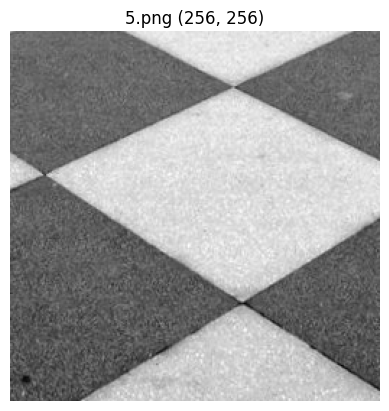

----- FRQI -----

 Performing FRQI Sobel Gradient Encoding ----- 

 Performing FRQI Sobel Gradient Encoding along x-direction ----- 

 Performing FRQI Sobel Gradient Encoding along y-direction ----- 
FRQI Sobel Gradient Encoding Complete! Elapsed time: 0.446189 seconds


 Retreiving FRQI Sobel Gradient ----- 
FRQI Sobel Gradient Retrieval Complete! Elapsed time: 0.872722 seconds


 Performing FRQI QHED Gradient Encoding ----- 

 Performing FRQI QHED Gradient Encoding along x-direction ----- 

 Performing FRQI QHED Gradient Encoding along y-direction ----- 
FRQI QHED Gradient Encoding Complete! Elapsed time: 0.462906 seconds


 Retreiving FRQI QHED Gradient ----- 
FRQI QHED Gradient Retrieval Complete! Elapsed time: 0.629332 seconds

FRQI: Corner Detection using Sobel Kernel


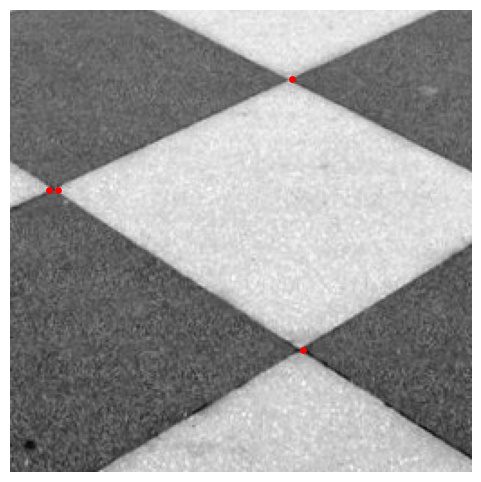

FRQI: Corner Detection using QHED


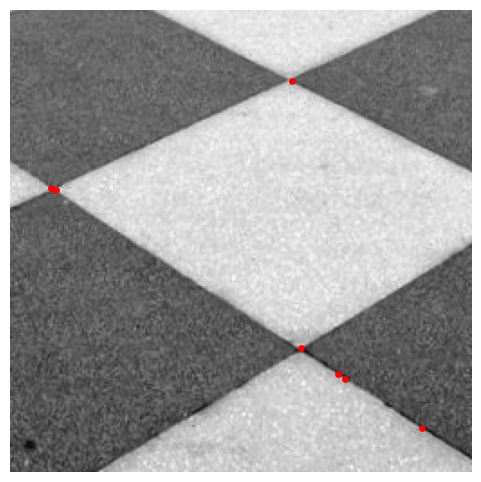

In [132]:
pixel_size = 256
# threshold = [0.225, 0.2, 0.15,0.225]
# threshold = [0.375, 0.2, 0.32, 0.15, 0.35] ### Animal Dataset (Eagle, Lion, Deer, Dog,Cat)
# threshold = [0.125,0.2,0.125,0.1,0.2,0.25,0.13, 0.12] ### (Caterpillar,Duck,House,Elephant,Kitchen,Photographer,Lawn,HouseTree)

HCD_k = [0.05]*file_count
HCD_window_size = [7]*file_count
HCD_gaussian_sigma = 1.5
t = [0.5]*file_count

file_no = 4

i_file = 0
# Iterate over all files in the dataset
for entry in dataset_path.iterdir():

    # Optionally, filter to only process image files based on their extension
    if entry.is_file() and entry.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:

        if i_file != file_no:
          i_file = i_file + 1
          continue

        print("\n Image File: ", entry.name)

        img_file = entry.name
        # img_name = img_file.split('.')[0]  # Split by '.' and take the first part
        # otherwise use entry.stem (name of the file without extension)

        image_path = dataset_path / img_file
        test_image = load_and_display_image(image_path,display_img = False)

        print("\n --------------------------------------------- \n")

        print("\n Image Size: ", pixel_size, "x", pixel_size)
        image = resize_image(test_image, (pixel_size,pixel_size))
        plot_image(image,entry.name)

       # ####################################################################################
        # ####################################################################################

        print("----- FRQI -----")
        ##################### FRQI SOBEL Kernel #####################
        ########## Encoding ##########
        print("\n Performing FRQI Sobel Gradient Encoding ----- ")

        start_time = time.perf_counter()

        print("\n Performing FRQI Sobel Gradient Encoding along x-direction ----- ")
        qc_frqi_x, frqi_grad_type = frqi_gradient(image,grad_type='lag2')

        print("\n Performing FRQI Sobel Gradient Encoding along y-direction ----- ")
        qc_frqi_y, frqi_grad_type = frqi_gradient(image.T,grad_type='lag2')

        end_time = time.perf_counter()
        elapsed_seconds = end_time - start_time
        print(f"FRQI Sobel Gradient Encoding Complete! Elapsed time: {elapsed_seconds:.6f} seconds\n")

        ##### Decoding
        print("\n Retreiving FRQI Sobel Gradient ----- ")

        start_time = time.perf_counter()

        frqi_statevector_x = run_simulation_statevector(qc_frqi_x,backend_sim)
        frqi_statevector_y = run_simulation_statevector(qc_frqi_y,backend_sim)

        frqi_grad_x = retrieve_grad_frqi(frqi_statevector_x,frqi_grad_type, Sobel = True)
        frqi_grad_y = retrieve_grad_frqi(frqi_statevector_y,frqi_grad_type, Sobel = True)

        end_time = time.perf_counter()
        elapsed_seconds = end_time - start_time
        print(f"FRQI Sobel Gradient Retrieval Complete! Elapsed time: {elapsed_seconds:.6f} seconds\n")

        ## CORNER DETECTION
        R_frqi_Sobel = HCD_response(image,frqi_grad_x,frqi_grad_y.T,HCD_window_size[i_file], HCD_k[i_file], kernel = 'Gaussian', gaussian_sigma = HCD_gaussian_sigma)
        R_frqi_Sobel = (R_frqi_Sobel - R_frqi_Sobel.min()) / (R_frqi_Sobel.max() - R_frqi_Sobel.min())
        threshold = t[i_file] # * R_frqi_Sobel.max()
        corners_frqi_Sobel = HCD_corner(image, R_frqi_Sobel, threshold)

        # ####################################################################################
        # ####################################################################################

        # ##################### FRQI QHED #####################
        # ########## Encoding ##########
        print("\n Performing FRQI QHED Gradient Encoding ----- ")

        start_time = time.perf_counter()

        print("\n Performing FRQI QHED Gradient Encoding along x-direction ----- ")
        qc_frqi_x_QHED, frqi_grad_type_QHED = frqi_gradient(image,grad_type='lag1')

        print("\n Performing FRQI QHED Gradient Encoding along y-direction ----- ")
        qc_frqi_y_QHED, frqi_grad_type_QHED = frqi_gradient(image.T,grad_type='lag1')
        # print(qc_FRQI.draw())

        end_time = time.perf_counter()
        elapsed_seconds = end_time - start_time
        print(f"FRQI QHED Gradient Encoding Complete! Elapsed time: {elapsed_seconds:.6f} seconds\n")

        ##### Decoding
        print("\n Retreiving FRQI QHED Gradient ----- ")

        start_time = time.perf_counter()

        frqi_statevector_x_QHED = run_simulation_statevector(qc_frqi_x_QHED,backend_sim)
        frqi_statevector_y_QHED = run_simulation_statevector(qc_frqi_y_QHED,backend_sim)

        frqi_grad_x_QHED = retrieve_grad_frqi(frqi_statevector_x_QHED,frqi_grad_type_QHED)
        frqi_grad_y_QHED = retrieve_grad_frqi(frqi_statevector_y_QHED,frqi_grad_type_QHED)

        end_time = time.perf_counter()
        elapsed_seconds = end_time - start_time
        print(f"FRQI QHED Gradient Retrieval Complete! Elapsed time: {elapsed_seconds:.6f} seconds\n")

        ## CORNER DETECTION
        R_frqi_QHED = HCD_response(image,frqi_grad_x_QHED,frqi_grad_y_QHED.T,HCD_window_size[i_file], HCD_k[i_file], kernel = 'Gaussian', gaussian_sigma = HCD_gaussian_sigma)
        R_frqi_QHED = (R_frqi_QHED - R_frqi_QHED.min()) / (R_frqi_QHED.max() - R_frqi_QHED.min())
        threshold = t[i_file] # * R_frqi_QHED.max()
        corners_frqi_QHED = HCD_corner(image, R_frqi_QHED, threshold)

        # ####################################################################################
        # ####################################################################################

        print("FRQI: Corner Detection using Sobel Kernel")
        corner_fig_frqi_Sobel = plot_harris_corners(image, corners_frqi_Sobel)
        corner_fig_frqi_Sobel.show()
        plt.show()  # Prevents merging with next plot

        #### Sobel Saving ####
        img_output_name = f"FRQI_{entry.stem}_Sobel.jpg"
        output_path = dataset_path.parent / 'Corner Detection using Sobel' / img_output_name
        save_figure(corner_fig_frqi_Sobel, file_name = output_path)

        print("FRQI: Corner Detection using QHED")
        corner_fig_frqi_QHED = plot_harris_corners(image, corners_frqi_QHED)
        corner_fig_frqi_QHED.show()
        plt.show()  # Prevents merging with next plot

        #### Sobel Saving ####
        img_output_name = f"FRQI_{entry.stem}_QHED.jpg"
        output_path = dataset_path.parent / 'Corner Detection using QHED' / img_output_name
        save_figure(corner_fig_frqi_QHED, file_name = output_path)

        i_file = i_file + 1

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pathlib import Path

# Define dataset paths
dataset_path = Path('./drive/MyDrive/QHCD/UrbanDataset')
images_path = dataset_path / 'Images'
gt_path = dataset_path / 'Ground Truth'

# List all image files
image_files = sorted(images_path.glob('*.*'))  # supports jpg, png, etc.

for image_file in image_files:
    # Load image in grayscale
    img = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)

    # Load corresponding ground truth corner file
    gt_file = gt_path / (image_file.stem + '.txt')
    if not gt_file.exists():
        print(f"Ground truth file missing for: {image_file.name}")
        continue

    # Load corner coordinates
    try:
        corners = np.loadtxt(gt_file)
        if corners.ndim == 1:  # Single point case
            corners = corners[np.newaxis, :]
    except Exception as e:
        print(f"Failed to read {gt_file.name}: {e}")
        continue

    # Create the plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap='gray')
    ax.scatter(corners[:, 1], corners[:, 0], c='red', s=20, marker='x', label='True Corners')
    ax.set_title(f"Ground Truth Corners: {image_file.name}")
    ax.axis('off')
    ax.legend()

    # Save the figure in Ground Truth/ folder
    output_file = gt_path / f"{image_file.stem}_ground_truth.jpg"
    fig.savefig(output_file, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.close(fig)
    print(f"Saved: {output_file}")


Ground truth file missing for: .DS_Store
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/1_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/10_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/11_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/12_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/13_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/14_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/15_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/16_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/17_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/18_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/19_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/2_ground_truth.jpg
Saved: drive/MyDrive/QHCD/UrbanDataset/Ground Truth/20_ground_truth.jpg
Saved: drive/MyDrive/QHCD